In [2]:
import pandas as pd
import numpy as np 

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, roc_curve, roc_auc_score

from sklearn.svm import LinearSVC, SVC
from sklearn.linear_model import LogisticRegression, SGDClassifier, Perceptron
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.dummy import DummyClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from xgboost import XGBClassifier
from sklearn.cluster import KMeans

import matplotlib.pyplot as plt
from seaborn import heatmap

In [3]:
# Import du jeu de données
df = pd.read_csv("./data/3-selected/data.csv")
df.head()

,perimeter_mean,radius_se,texture_worst,concavity_mean,concave points_worst,compactness_mean,texture_se,fractal_dimension_mean,fractal_dimension_worst,smoothness_mean,fractal_dimension_se,symmetry_se,smoothness_se,symmetry_worst,symmetry_mean,smoothness_worst,concave points_se,compactness_se,concavity_se,diagnosis
0,1.269934,2.489734,-1.359293,2.652874,2.296076,3.283515,-0.565265,2.255747,1.937015,1.568466,0.907083,1.148757,-0.214002,2.750622,2.217515,1.307686,0.660820,1.316862,0.724026,1
1,1.685955,0.499255,-0.369203,-0.023846,1.087084,-0.487072,-0.876244,-0.868652,0.281190,-0.826962,-0.099444,-0.805450,-0.605351,-0.243890,0.001392,-0.375612,0.260162,-0.692926,-0.440780,1
2,1.566503,1.228676,-0.023974,1.363478,1.955000,1.052926,-0.780083,-0.398008,0.201391,0.942210,0.293559,0.237036,-0.297005,1.152255,0.939685,0.527407,1.424827,0.814974,0.213076,1
3,-0.592687,0.326373,0.133984,1.915897,2.175786,3.402909,-0.110409,4.910919,4.935010,3.283553,2.047511,4.732680,0.689702,6.046041,2.867383,3.394275,1.115007,2.744280,0.819518,1
4,1.776573,1.270543,-1.466770,1.371011,0.729259,0.539340,-0.790244,-0.562450,-0.397100,0.280372,0.499328,-0.361092,1.483067,-0.868353,-0.009560,0.220556,1.144205,-0.048520,0.828471,1


In [4]:
# Séparation des données d'entrainement et de validation
train, test = train_test_split(
    df,                         # Dataset
    stratify=df["diagnosis"],   # Stratification par la colonne cible
    test_size=0.25,             # 25% des données reservées à la validation
    shuffle=True,               # Mélanger les données, empêcher un biais
    random_state=42,
)

# Vérification du découpage
print(f"Dimensions du dataset: {df.shape}")
print(f"Dimensions de 'train': {train.shape}")
print(f"Dimensions de 'test': {test.shape}")

# Séparation des colonnes "features" de la colonne "target"
X_train = train.drop(columns="diagnosis")       # Colonnes features d'entrainement 
Y_train = train["diagnosis"]                    # Colonne target d'entrainement 
X_test = test.drop(columns="diagnosis")         # Colonnes features de validation 
Y_test = test["diagnosis"]                      # Colonne target de validation 

# Vérification des dimensions 
print()
print(f"Dimensions de X_train : {X_train.shape}")
print(f"Dimensions de Y_train : {Y_train.shape}")
print(f"Dimensions de X_test : {X_test.shape}")
print(f"Dimensions de Y_test : {Y_test.shape}")

Dimensions du dataset: (569, 20)
Dimensions de 'train': (426, 20)
Dimensions de 'test': (143, 20)

Dimensions de X_train : (426, 19)
Dimensions de Y_train : (426,)
Dimensions de X_test : (143, 19)
Dimensions de Y_test : (143,)


In [ ]:
# Création d'une fonction d'évaluation et d'obtentions des metriques
def evaluate(results, model, X_train, Y_train, X_test, Y_test):
    model_name = type(model).__name__        # Obtention du nom du modèle
    
    model.fit(X_train, Y_train)             # Entrainement du modèle
    Y_pred = model.predict(X_test)          # Création des prédictions

    # Obtentions des scores pour chaque prédiction individuelle 
    if hasattr(model, "predict_proba"):
        Y_pred_score = model.predict_proba(X_test)[:, 1]    # Probabilités
    elif hasattr(model, "decision_function"):
        Y_pred_score = model.decision_function(X_test)      # Scores
    else:
        Y_pred_score = None

    # Évaluations des prédictions
    results[model_name] = {
        "cm": confusion_matrix(Y_test, Y_pred),
        "roc_curve": roc_curve(Y_test, Y_pred_score) if (Y_pred_score is not None) else None,
        "roc_auc": roc_auc_score(Y_test, Y_pred_score) if (Y_pred_score is not None) else None
    }

    return results

In [55]:
# Création d'un dictionnaire de résultats
metrics = {}

# LinearSVC
metrics = evaluate(metrics, LinearSVC(), X_train, Y_train, X_test, Y_test)

# SVC
metrics = evaluate(metrics, SVC(), X_train, Y_train, X_test, Y_test)

# LogisticRegression
metrics = evaluate(metrics, LogisticRegression(), X_train, Y_train, X_test, Y_test)

# SGDClassifier
metrics = evaluate(metrics, SGDClassifier(), X_train, Y_train, X_test, Y_test)

# Perceptron
metrics = evaluate(metrics, Perceptron(), X_train, Y_train, X_test, Y_test)

# RandomForestClassifier
metrics = evaluate(metrics, RandomForestClassifier(), X_train, Y_train, X_test, Y_test)

# KNeighborsClassifier
metrics = evaluate(metrics, KNeighborsClassifier(), X_train, Y_train, X_test, Y_test)

# DecisionTreeClassifier
metrics = evaluate(metrics, DecisionTreeClassifier(), X_train, Y_train, X_test, Y_test)

# GaussianNB
metrics = evaluate(metrics, GaussianNB(), X_train, Y_train, X_test, Y_test)

# XGBClassifier
metrics = evaluate(metrics, XGBClassifier(), X_train, Y_train, X_test, Y_test)

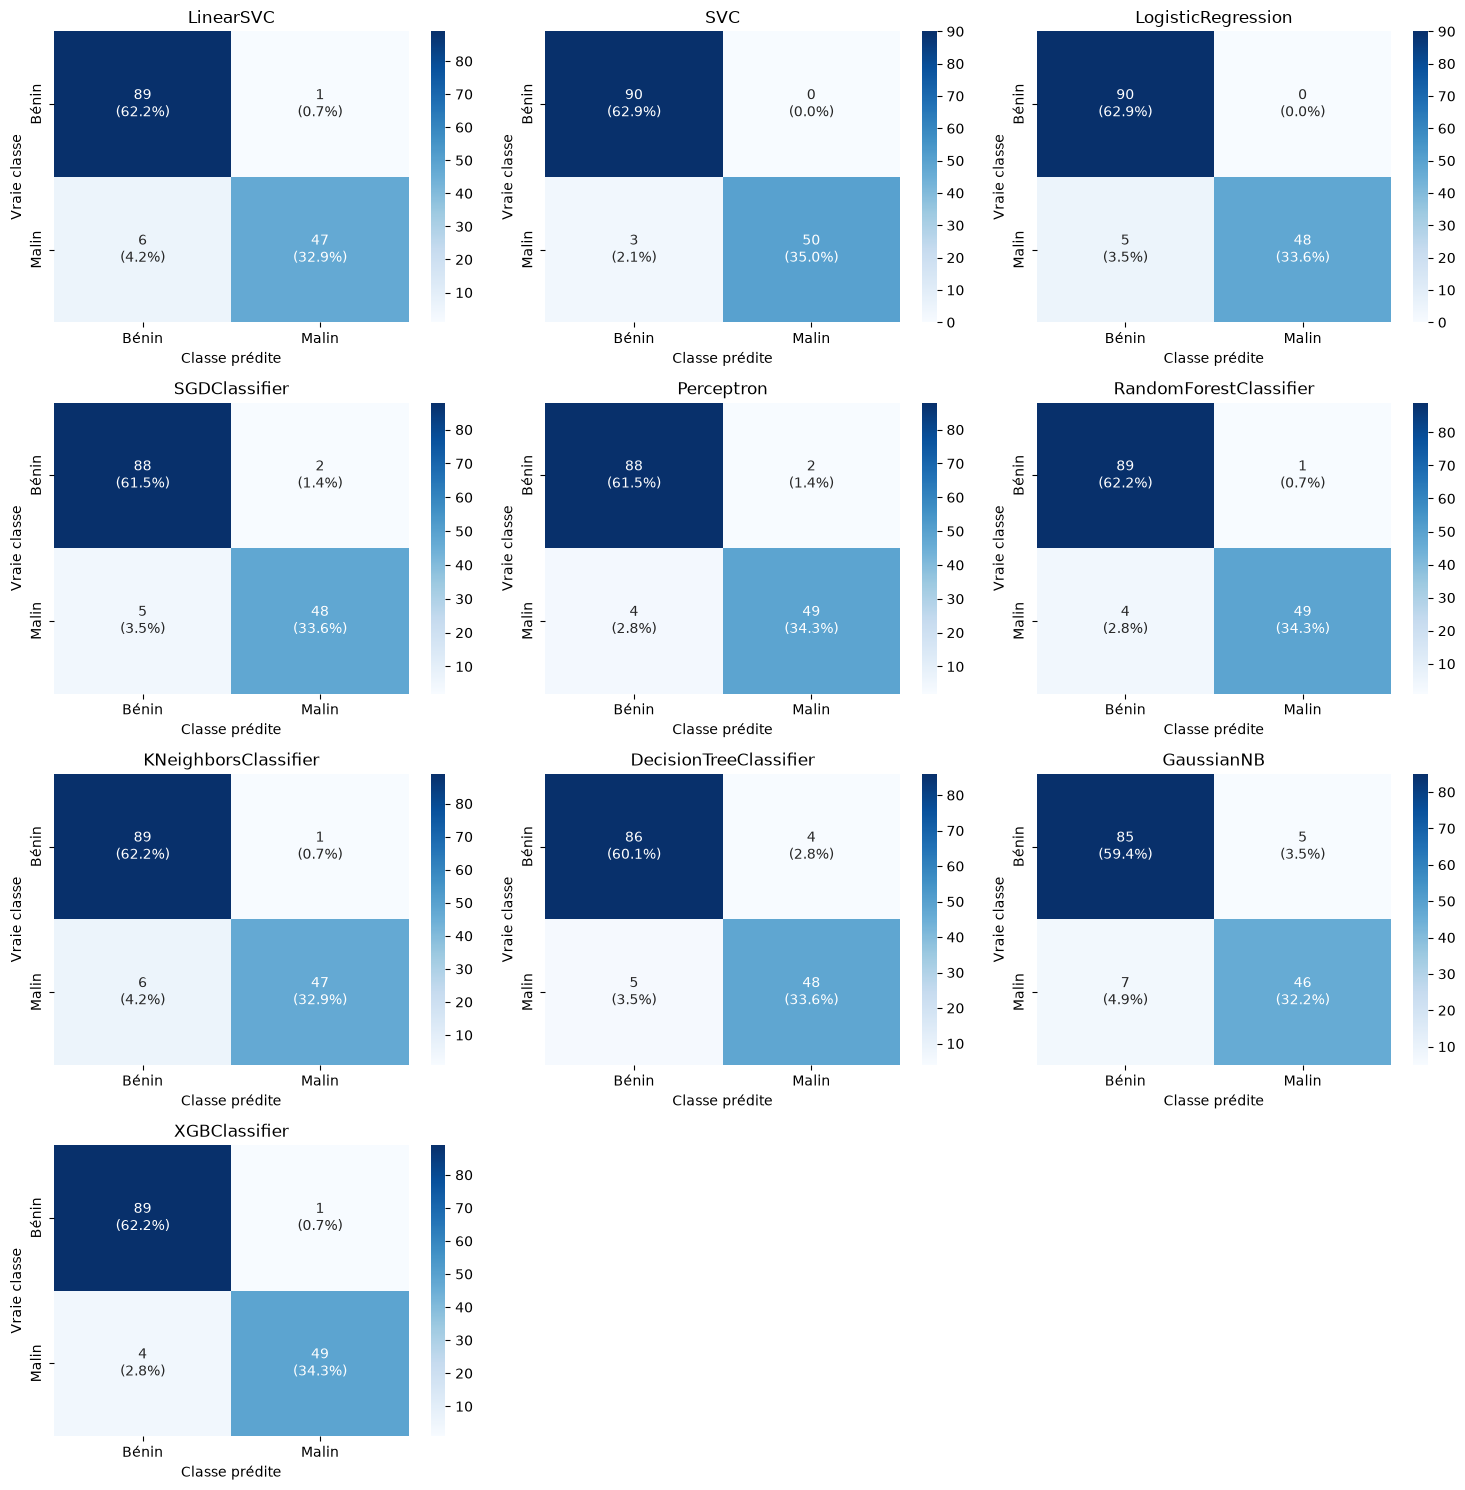

In [56]:
# VISUALISATION - Matrices de confusion

fig, axes = plt.subplots(4, 3, figsize=(15, 15))
axes = axes.flatten()

for idx, (model_name, model_metrics) in enumerate(metrics.items()):
    cm = model_metrics["cm"]                            # Obtention des données
    cm_percent = cm.astype('float') / cm.sum() * 100    # Calcul des pourcentages

    # Création des annotations 
    annotations = np.empty_like(cm, dtype=object)
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            annotations[i, j] = f'{cm[i, j]}\n({cm_percent[i, j]:.1f}%)'

    # Matrice de confusion
    heatmap(cm, fmt='', cmap='Blues', annot=annotations, ax=axes[idx],
            xticklabels=['Bénin', 'Malin'], yticklabels=['Bénin', 'Malin'])

    # Légendes 
    axes[idx].set_title(model_name)
    axes[idx].set_ylabel("Vraie classe", fontsize=10)
    axes[idx].set_xlabel("Classe prédite", fontsize=10)

# Supprimer les sous-graphiques non utilisés
for idx in range(len(metrics), len(axes)):
    fig.delaxes(axes[idx])

plt.tight_layout()
plt.show()

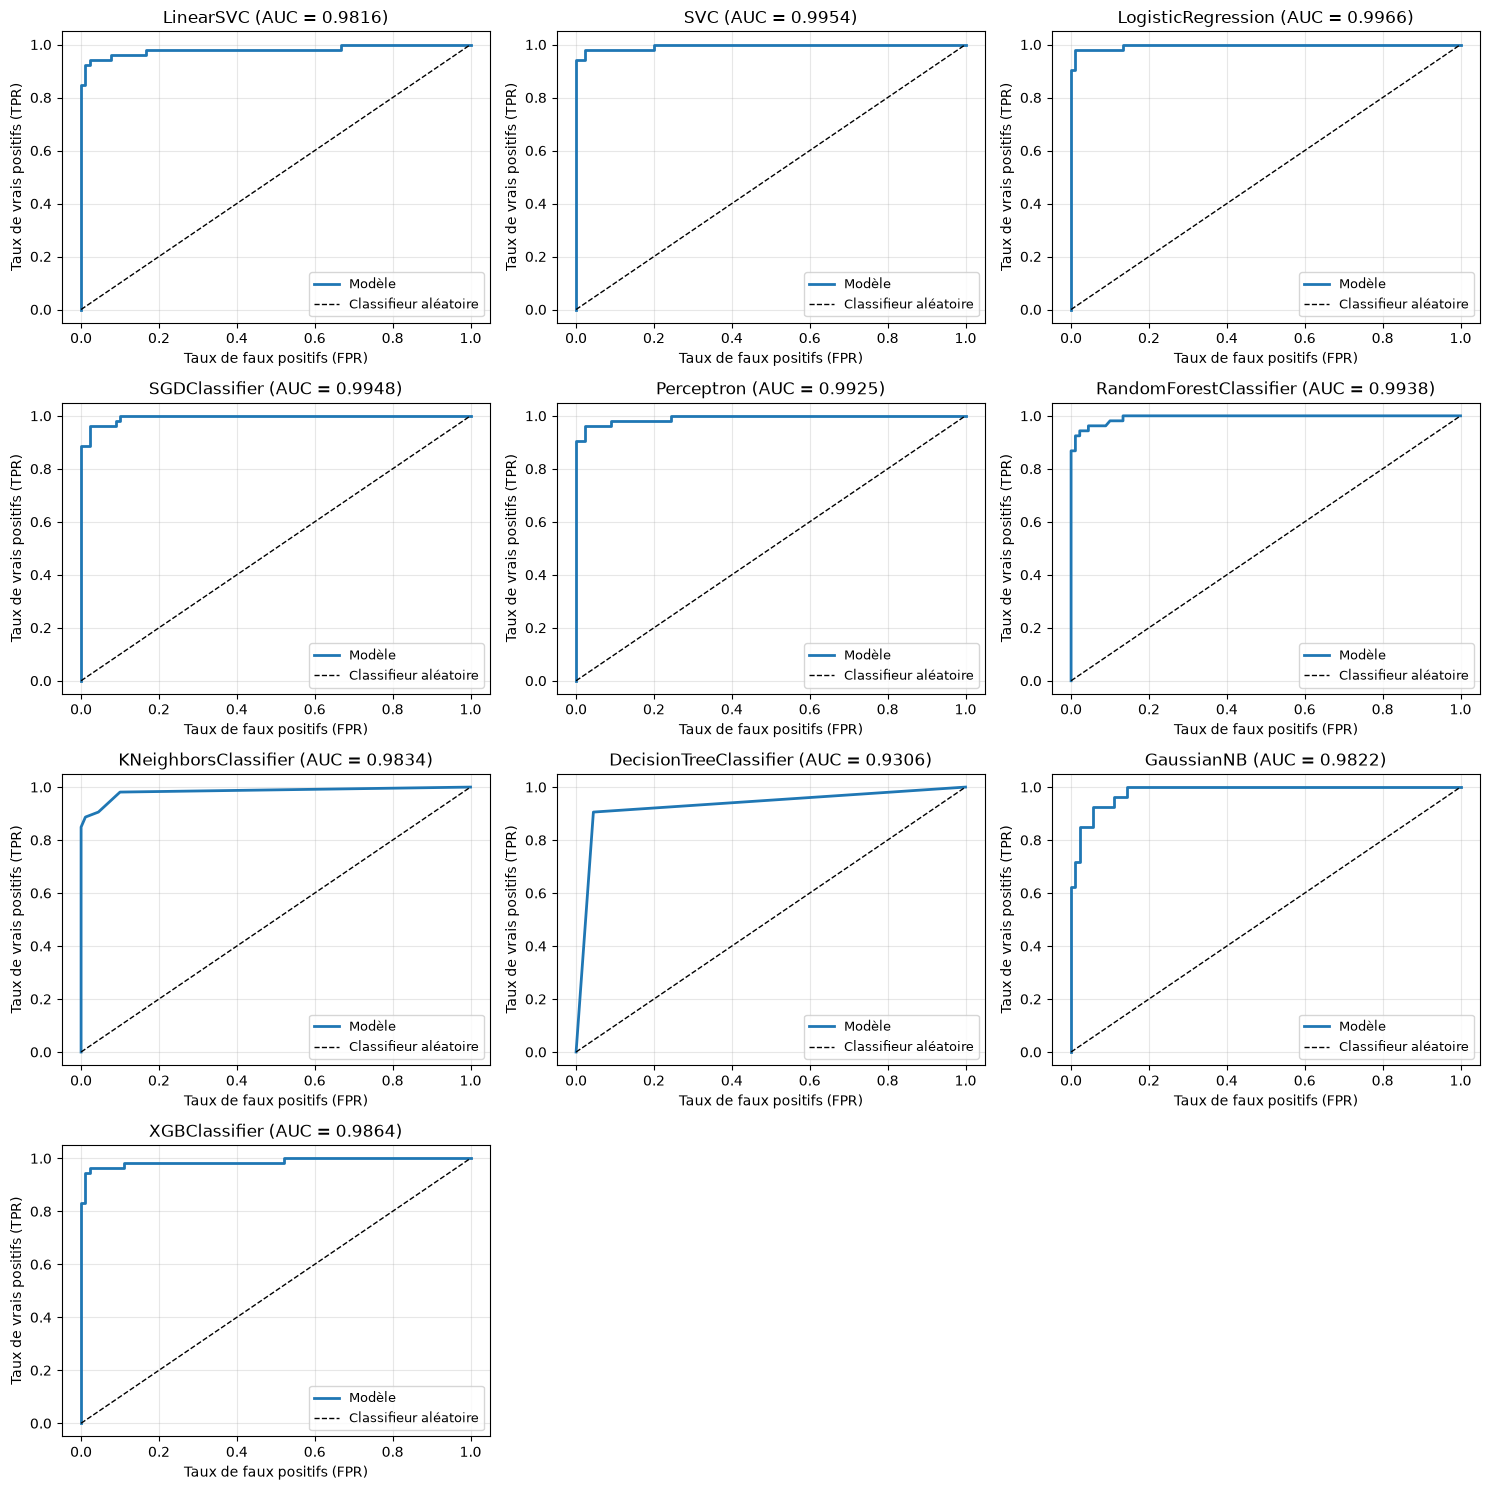

In [57]:
# VISUALISATION - Courbes ROC séparées

# Conservation des seuls modèles disposant d'une courbe ROC
roc_metrics = {name: m for name, m in metrics.items() if m["roc_auc"] is not None}

fig, axes = plt.subplots(4, 3, figsize=(15, 15))
axes = axes.flatten()

for idx, (model_name, model_metrics) in enumerate(roc_metrics.items()):
    fpr, tpr, _ = model_metrics["roc_curve"]    # Obtention des métriques

    # Courbe ROC cas aléatoire en diagonale
    axes[idx].plot(fpr, tpr, linewidth=2, label="Modèle")
    axes[idx].plot([0, 1], [0, 1], 'k--', linewidth=1, label="Classifieur aléatoire")

    # Légendes
    axes[idx].set_title(f"{model_name} (AUC = {model_metrics['roc_auc']:.4f})")
    axes[idx].set_xlabel("Taux de faux positifs (FPR)", fontsize=10)
    axes[idx].set_ylabel("Taux de vrais positifs (TPR)", fontsize=10)
    axes[idx].legend(loc="lower right", fontsize=9)
    axes[idx].grid(alpha=0.3)

# Supprimer les sous-graphiques non utilisés
for idx in range(len(roc_metrics), len(axes)):
    fig.delaxes(axes[idx])

plt.tight_layout()
plt.show()

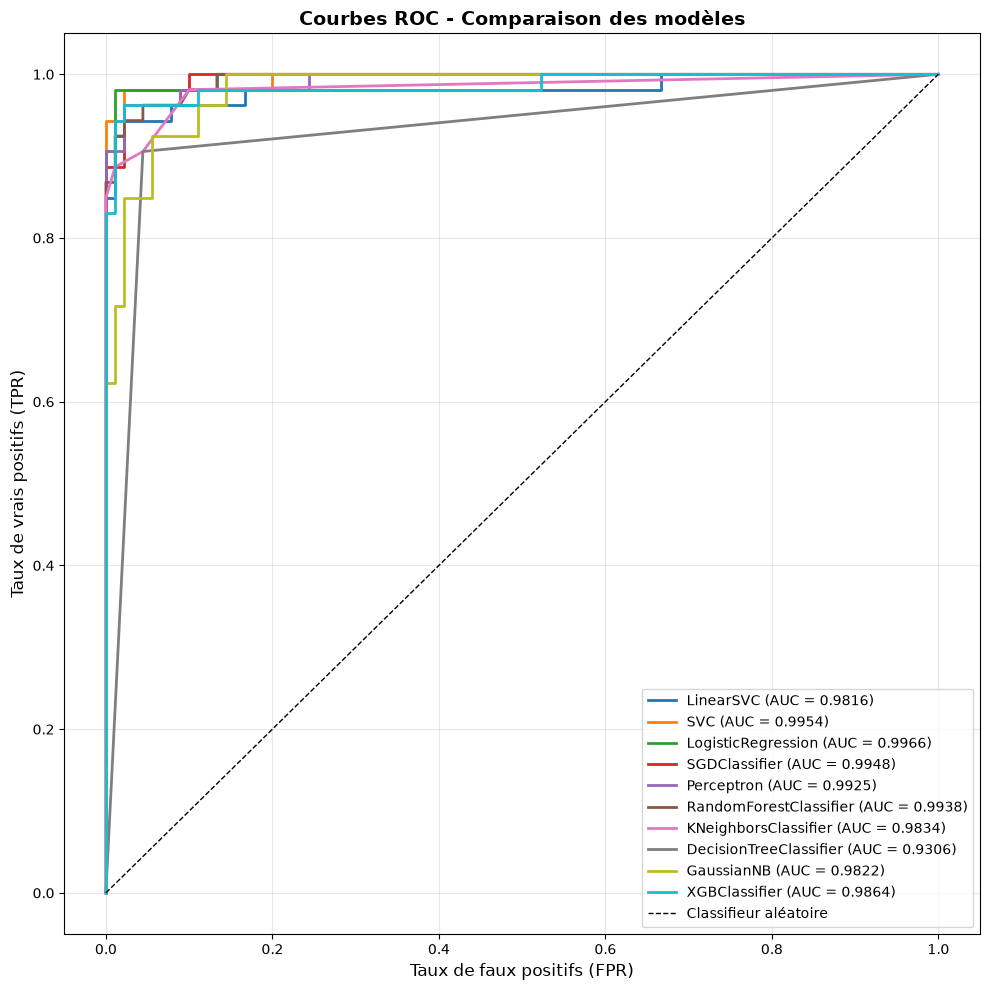

In [58]:
# VISUALISATION - Courbes ROC ensemble

plt.figure(figsize=(10, 10))

for model_name, model_metrics in metrics.items():
    if model_metrics["roc_auc"] is not None:
        fpr, tpr, _ = model_metrics["roc_curve"]                                                        # Obtention des métriques
        plt.plot(fpr, tpr, linewidth=2, label=f"{model_name} (AUC = {model_metrics['roc_auc']:.4f})")   # Graphe des métriques

# Cas aléatoire en diagonale
plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Classifieur aléatoire')

# Légendes
plt.xlabel('Taux de faux positifs (FPR)', fontsize=12)
plt.ylabel('Taux de vrais positifs (TPR)', fontsize=12)
plt.title('Courbes ROC - Comparaison des modèles', fontsize=14, fontweight='bold')
plt.legend(loc="lower right", fontsize=10)

# Affichage
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()